In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from hamiltonian_matrix import hamiltonian_matrix

In [9]:
def harmonic_osci(x):
    potential = 0.5 * x**2
    return potential

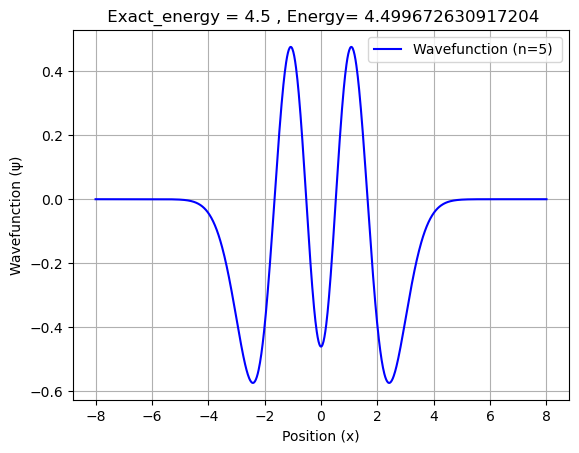

In [13]:
def solve_harmonic_oscilator(L,interior_points,state_number):
    if interior_points <= 0:
        raise ValueError("interior_points must be positive.")
    
    if state_number < 0 or state_number >= interior_points:
        raise ValueError("Invalid state_number.")
    if L <= 0:
        raise ValueError("length can not be negative.")
        
    dx = 2*L/(interior_points+1)
    x = np.linspace(-L+dx,L-dx, interior_points)
    x_full = np.linspace(-L, L, interior_points+2)
    
    potential_values = harmonic_osci(x)
    hamiltonian = hamiltonian_matrix(interior_points, dx, potential_values)
        
    eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
        
    phi_interior = eigenvectors[:, state_number]
    energy = eigenvalues[state_number]
    excat_energy = (state_number + 1/2)
    
    #normalisation:
    phi = np.concatenate(([0], phi_interior, [0]))
    norm = np.sum(np.abs(phi)**2)*dx
    phi_norm = phi/np.sqrt(norm)
    
    return x_full, phi_norm, energy, excat_energy

state_number = 4
x, phi, energy, exact_energy = solve_harmonic_oscilator(8,1000,state_number)  
plt.plot(x, phi, label=f'Wavefunction (n={state_number+1}) ' , color='blue')
plt.title(f' Exact_energy = {exact_energy} , Energy= {energy}')
plt.xlabel('Position (x)')
plt.ylabel('Wavefunction (ψ)')
plt.legend()
plt.grid(True)
plt.show()
